# CS 432 – Databases | Assignment 2 | Module A
## Lightweight DBMS with B+ Tree Index

**Course:** CS 432  Databases  
**Instructor:** Dr. Yogesh K. Meena  
**Semester:** Jan-May 2026  
**Institute:** Indian Institute of Technology, Gandhinagar

---

## Introduction

Most traditional database management systems (DBMS) use different kinds of indexing techniques to make data retrieval faster. But as the size of the data keeps growing, it becomes harder to keep everything running smoothly and quickly.

Common data structures like binary search trees (BSTs) and hash tables do a decent job for certain types of searches, but they start showing limitations when working with huge datasets — especially when it comes to range queries (like "find all records between A and B") and sequential access (like reading records in order).

To overcome these issues, this project proposes using a B+ Tree-based database indexing system. A B+ Tree is a special type of balanced tree that can handle insertion, deletion, and search operations efficiently, all in logarithmic time.

What makes B+ Trees particularly useful is how well they work with disk-based storage systems. They help reduce the number of disk read/write operations, which is a big deal when dealing with massive amounts of data.

The key properties that make a B+ Tree different from a regular B-Tree are:
- All actual data values are stored **only in leaf nodes**
- Internal nodes store only **separator keys** used purely for routing
- All leaf nodes are **linked together** via a `next` pointer, enabling fast range queries without revisiting the tree
- The tree remains **perfectly balanced** at all times — every leaf is at the same depth

This assignment implements a B+ Tree from scratch in Python and integrates it into a lightweight DBMS with `Table` and `DatabaseManager` abstractions. A BruteForce baseline (simple Python list) is also implemented for performance comparison.

### Theoretical Time Complexity Comparison

| Operation | B+ Tree | BruteForce |
|---|---|---|
| Search | O(log n) | O(n) |
| Insert | O(log n) | O(1) |
| Delete | O(log² n) | O(n) |
| Range Query | O(log n + k) | O(n) |

where n = total number of records and k = number of results returned by a range query.

---

## Implementation Details

### B+ Tree Node (`bplustreenode`)
Each node contains:
- `keys` — sorted list of keys
- `values` — actual records stored only at leaf nodes
- `children` — child node pointers used only in internal nodes
- `is_leaf` — flag to distinguish leaf from internal node
- `next` — pointer to the next leaf node (enables O(k) range traversal)
- `is_full(degree)` — checks if a node has reached maximum capacity

### B+ Tree (`bplustree`) with degree=4
Degree 4 means each node holds at most 3 keys and 4 children. When a node becomes full, it splits automatically.

**Insertion - O(log n):**  
Search first to check if key exists -update if found. Otherwise, if root is full, split root and create a new root. Traverse from root to correct leaf and insert in sorted order. `_split_child` copies the leftmost key of the right child up to the parent — no full-tree refresh needed.

**Deletion - O(log² n):**  
Traverse to the correct leaf and remove the key. If a node goes below minimum keys, borrow from a sibling or merge with it. After each recursive step, only the one separator key that could have become stale is updated using `_leftmost_key` — O(log n) per level, across O(log n) levels = O(log² n) total.

**Search - O(log n):**  
Traverse internal nodes using key comparisons down to the correct leaf, then do a linear scan within the leaf.

**Range Query — O(log n + k):**  
Find the leaf where `start_key` would be via tree traversal, then walk the `next` pointer chain collecting all keys until `end_key` is exceeded.

**Visualization:**  
Uses Graphviz `Digraph`. Gray boxes = internal nodes, Blue boxes = leaf nodes, Black arrows = parent→child, Red dashed arrows = leaf linked list.

### BruteForce (`Bruteforceindex`)
Stores all records in a plain Python list. Every operation except insert requires scanning the entire list — O(n). Used as a performance baseline.

### Table (`Table`)
Wraps the B+ Tree into a table abstraction with schema validation, a designated search key for indexing, and standard CRUD operations.

### DatabaseManager (`DatabaseManager`)
Manages multiple databases, each containing multiple tables. Provides features like `create_database`, `delete_database`, `create_table`, `delete_table`, `get_table`, `list_tables`.

In [5]:
!pip install graphviz
from graphviz import Digraph
from IPython.display import Image, display
import random
import time
import tracemalloc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

---
# Task 1 -- B+ Tree Implementation

### BruteForce Baseline

In [7]:
class Bruteforceindex:
  def __init__(self):
    self.data=[]
  def insert(self,key,value):
    found,a=self.search(key)
    if found:
      self.update(key,value)
    else:
      self.data.append((key,value))
  def search(self,key):
    for k,v in self.data:
      if k==key:
        return (True,v)
    return (False,None)
  def delete(self,key):
    for i,(k,v) in enumerate(self.data):
      if k==key:
        self.data.pop(i)
        return True
    return False
  def update(self,key,newval):
    for i,(k,v) in enumerate(self.data):
      if k==key:
        self.data[i]=(k,newval)
        return True
    return False
  def getall(self):
    return self.data.copy()
  def range_query(self,st,end):
    return [i for i in self.data if st<=i[0]<=end]

### B+ Tree Node and B+ Tree Classes

In [40]:
class bplustreenode:
    def __init__(self, is_leaf=False):
        self.is_leaf = is_leaf
        self.keys = []
        self.children = []   # internal nodes
        self.values = []     # leaf nodes
        self.next = None     # leaf linkage

    def is_full(self, degree):
        return len(self.keys) >= degree - 1


class bplustree:
    def __init__(self, degree=4):
        self.root = bplustreenode(True)
        self.degree = degree
        self.min_keys = (degree + 1) // 2 - 1   # for degree=4 -> 1

    # Search - O(log n)
    def search(self, key):
        node = self.root
        while not node.is_leaf:
            i = 0
            while i < len(node.keys) and key >= node.keys[i]:
                i += 1
            node = node.children[i]
        for i, item in enumerate(node.keys):
            if item == key:
                return (True, node.values[i])
        return (False, None)

    # Update - O(log n)
    def update(self, key, new_value):
        node = self.root
        while not node.is_leaf:
            i = 0
            while i < len(node.keys) and key >= node.keys[i]:
                i += 1
            node = node.children[i]
        for i, item in enumerate(node.keys):
            if item == key:
                node.values[i] = new_value
                return True
        return False

    # Insert - O(log n)
    def insert(self, key, value):
        found, _ = self.search(key)
        if found:
            self.update(key, value)
            return
        if len(self.root.keys) == self.degree - 1:
            new_root = bplustreenode(is_leaf=False)
            new_root.children.append(self.root)
            self._split_child(new_root, 0)
            self.root = new_root
        self._insert_non_full(self.root, key, value)

    def _insert_non_full(self, node, key, value):
        if node.is_leaf:
            idx = 0
            while idx < len(node.keys) and key > node.keys[idx]:
                idx += 1
            node.keys.insert(idx, key)
            node.values.insert(idx, value)
        else:
            idx = 0
            while idx < len(node.keys) and key > node.keys[idx]:
                idx += 1
            if len(node.children[idx].keys) == self.degree - 1:
                self._split_child(node, idx)
                if idx < len(node.keys) and key >= node.keys[idx]:
                    idx += 1
            self._insert_non_full(node.children[idx], key, value)

    def _split_child(self, parent, index):
        node = parent.children[index]
        new_node = bplustreenode(is_leaf=node.is_leaf)
        if node.is_leaf:
            mid = len(node.keys) // 2
            new_node.keys = node.keys[mid:]
            new_node.values = node.values[mid:]
            node.keys = node.keys[:mid]
            node.values = node.values[:mid]
            parent.keys.insert(index, new_node.keys[0])
            parent.children.insert(index + 1, new_node)
            new_node.next = node.next
            node.next = new_node
        else:
            mid = len(node.keys) // 2
            up_key = node.keys[mid]
            new_node.keys = node.keys[mid + 1:]
            new_node.children = node.children[mid + 1:]
            node.keys = node.keys[:mid]
            node.children = node.children[:mid + 1]
            parent.keys.insert(index, up_key)
            parent.children.insert(index + 1, new_node)

    # Delete - O(log^2 n)
    def delete(self, key):
        if not self.root or len(self.root.keys) == 0 and self.root.is_leaf:
            return False
        deleted = self._delete(self.root, key)
        if deleted:
            while not self.root.is_leaf and len(self.root.keys) == 0 and self.root.children:
                self.root = self.root.children[0]
        return deleted

    def _delete(self, node, key):
        if node.is_leaf:
            if key in node.keys:
                idx = node.keys.index(key)
                node.keys.pop(idx)
                node.values.pop(idx)
                return True
            return False
        idx = 0
        while idx < len(node.keys) and key >= node.keys[idx]:
            idx += 1
        if len(node.children[idx].keys) == self.min_keys:
            idx = self._fill_child(node, idx)
        deleted = self._delete(node.children[idx], key)
        # update only the one separator that could have changed
        if deleted and idx > 0:
            new_min = self._leftmost_key(node.children[idx])
            if new_min is not None:
                node.keys[idx - 1] = new_min
        return deleted

    def _fill_child(self, node, idx):
        if idx > 0 and len(node.children[idx - 1].keys) > self.min_keys:
            self._borrow_from_prev(node, idx)
            return idx
        if idx < len(node.children) - 1 and len(node.children[idx + 1].keys) > self.min_keys:
            self._borrow_from_next(node, idx)
            return idx
        if idx < len(node.children) - 1:
            self._merge(node, idx)
            return idx
        else:
            self._merge(node, idx - 1)
            return idx - 1

    def _borrow_from_prev(self, node, index):
        child = node.children[index]
        sibling = node.children[index - 1]
        if child.is_leaf:
            child.keys.insert(0, sibling.keys.pop(-1))
            child.values.insert(0, sibling.values.pop(-1))
            node.keys[index - 1] = child.keys[0]
        else:
            child.keys.insert(0, node.keys[index - 1])
            node.keys[index - 1] = sibling.keys.pop(-1)
            child.children.insert(0, sibling.children.pop(-1))

    def _borrow_from_next(self, node, index):
        child = node.children[index]
        sibling = node.children[index + 1]
        if child.is_leaf:
            child.keys.append(sibling.keys.pop(0))
            child.values.append(sibling.values.pop(0))
            node.keys[index] = sibling.keys[0]
        else:
            child.keys.append(node.keys[index])
            node.keys[index] = sibling.keys.pop(0)
            child.children.append(sibling.children.pop(0))

    def _merge(self, node, index):
        child = node.children[index]
        sibling = node.children[index + 1]
        if child.is_leaf:
            child.keys.extend(sibling.keys)
            child.values.extend(sibling.values)
            child.next = sibling.next
        else:
            child.keys.append(node.keys[index])
            child.keys.extend(sibling.keys)
            child.children.extend(sibling.children)
        node.keys.pop(index)
        node.children.pop(index + 1)

    # Range Query - O(log n + k)
    def range_query(self, st, end):
        node = self.root
        while not node.is_leaf:
            i = 0
            while i < len(node.keys) and st >= node.keys[i]:
                i += 1
            node = node.children[i]
        result = []
        while node is not None:
            for i, key in enumerate(node.keys):
                if st <= key <= end:
                    result.append((key, node.values[i]))
                elif key > end:
                    return result
            node = node.next
        return result

    def get_all(self):
        result = []
        node = self.root
        while not node.is_leaf:
            node = node.children[0]
        while node:
            for key, value in zip(node.keys, node.values):
                result.append((key, value))
            node = node.next
        return result

    # Helper - leftmost key of a subtree
    def _leftmost_key(self, node):
        while node and not node.is_leaf:
            node = node.children[0]
        if node and node.keys:
            return node.keys[0]
        return None

    # Visualization
    def visualize_tree(self, filename="bplustree"):
        dot = Digraph(format='png')
        dot.attr(dpi='300')
        dot.attr(rankdir='TB')
        self._add_nodes(dot, self.root)
        self._add_edges(dot, self.root)
        leaf = self.root
        while leaf and not leaf.is_leaf:
            leaf = leaf.children[0] if leaf.children else None
        while leaf and leaf.next:
            dot.edge(str(id(leaf)), str(id(leaf.next)),
                     style='dashed', color='red', constraint='false')
            leaf = leaf.next
        return dot

    def _add_nodes(self, dot, node):
        if node is None:
            return
        node_id = str(id(node))
        label = " | ".join(str(k) for k in node.keys) if node.keys else "∅"
        if node.is_leaf:
            dot.node(node_id, label=label, shape="box", style="filled", color="lightblue")
        else:
            dot.node(node_id, label=label, shape="box", style="filled", color="lightgray")
        if not node.is_leaf:
            for child in node.children:
                self._add_nodes(dot, child)

    def _add_edges(self, dot, node):
        if node is None or node.is_leaf:
            return
        parent_id = str(id(node))
        for child in node.children:
            dot.edge(parent_id, str(id(child)))
            self._add_edges(dot, child)

### Demo - Insertion, Search, Update, Range Query, Deletion

In [11]:
def run_bplus_tree():
    print("Creating B+ Tree with degree=4")
    tree = bplustree(4)

    print("\n--- Insertion ---")
    for k in [10, 20, 30, 40, 50, 60, 90, 100, 110]:
        print(f"Inserting key {k} with value 'DATA1'")
        tree.insert(k, "DATA1")
    for k in [5, 25, 35, 75, 85, 95, 105, 115]:
        print(f"Inserting key {k} with value 'DATA2'")
        tree.insert(k, "DATA2")
    for k in [7, 17, 37, 47, 57]:
        print(f"Inserting key {k} with value 'DATA3'")
        tree.insert(k, "DATA3")

    print("\n--- Search ---")
    for key in [30, 47, 65]:
        found, value = tree.search(key)
        if found:
            print(f"Key {key} found with value '{value}'")
        else:
            print(f"Key {key} not found")

    print("\n--- Range Query (20 to 58) ---")
    print(tree.range_query(20, 58))

    print("\n--- Update key 57 ---")
    tree.update(57, "updated-57")
    print("After update:", tree.search(57))

    print("\n--- Deletion ---")
    for key in [17, 35, 105, 40]:
        print(f"Deleting key {key}")
        tree.delete(key)
        print("Current keys:", [k for k, v in tree.get_all()])

run_bplus_tree()

Creating B+ Tree with degree=4

--- Insertion ---
Inserting key 10 with value 'DATA1'
Inserting key 20 with value 'DATA1'
Inserting key 30 with value 'DATA1'
Inserting key 40 with value 'DATA1'
Inserting key 50 with value 'DATA1'
Inserting key 60 with value 'DATA1'
Inserting key 90 with value 'DATA1'
Inserting key 100 with value 'DATA1'
Inserting key 110 with value 'DATA1'
Inserting key 5 with value 'DATA2'
Inserting key 25 with value 'DATA2'
Inserting key 35 with value 'DATA2'
Inserting key 75 with value 'DATA2'
Inserting key 85 with value 'DATA2'
Inserting key 95 with value 'DATA2'
Inserting key 105 with value 'DATA2'
Inserting key 115 with value 'DATA2'
Inserting key 7 with value 'DATA3'
Inserting key 17 with value 'DATA3'
Inserting key 37 with value 'DATA3'
Inserting key 47 with value 'DATA3'
Inserting key 57 with value 'DATA3'

--- Search ---
Key 30 found with value 'DATA1'
Key 47 found with value 'DATA3'
Key 65 not found

--- Range Query (20 to 58) ---
[(20, 'DATA1'), (25, 'DATA2

---
# Task 2 -- Performance Analyzer

In [15]:
class PerformanceAnalyzer:
    def __init__(self, ds):
        self.ds = ds

    def measure_time_memory(self, func, *args):
        tracemalloc.start()
        start = time.perf_counter()
        func(*args)
        end = time.perf_counter()
        current, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        return end - start, peak / 1024  # time in seconds, memory in KB

    def insert_bulk(self, keys):
        for k in keys:
            self.ds.insert(k, str(k))

    def search_bulk(self, keys):
        for k in keys:
            self.ds.search(k)

    def delete_bulk(self, keys):
        for k in keys:
            self.ds.delete(k)

    def range_bulk(self, ranges):
        for l, r in ranges:
            self.ds.range_query(l, r)

---
# Task 3 -- Tree Visualization

- **Gray boxes** = internal nodes (store separator keys for routing only)
- **Blue boxes** = leaf nodes (store actual key-value data)
- **Black arrows** = parent → child relationships
- **Red dashed arrows** = leaf node linked list (enables fast range queries)

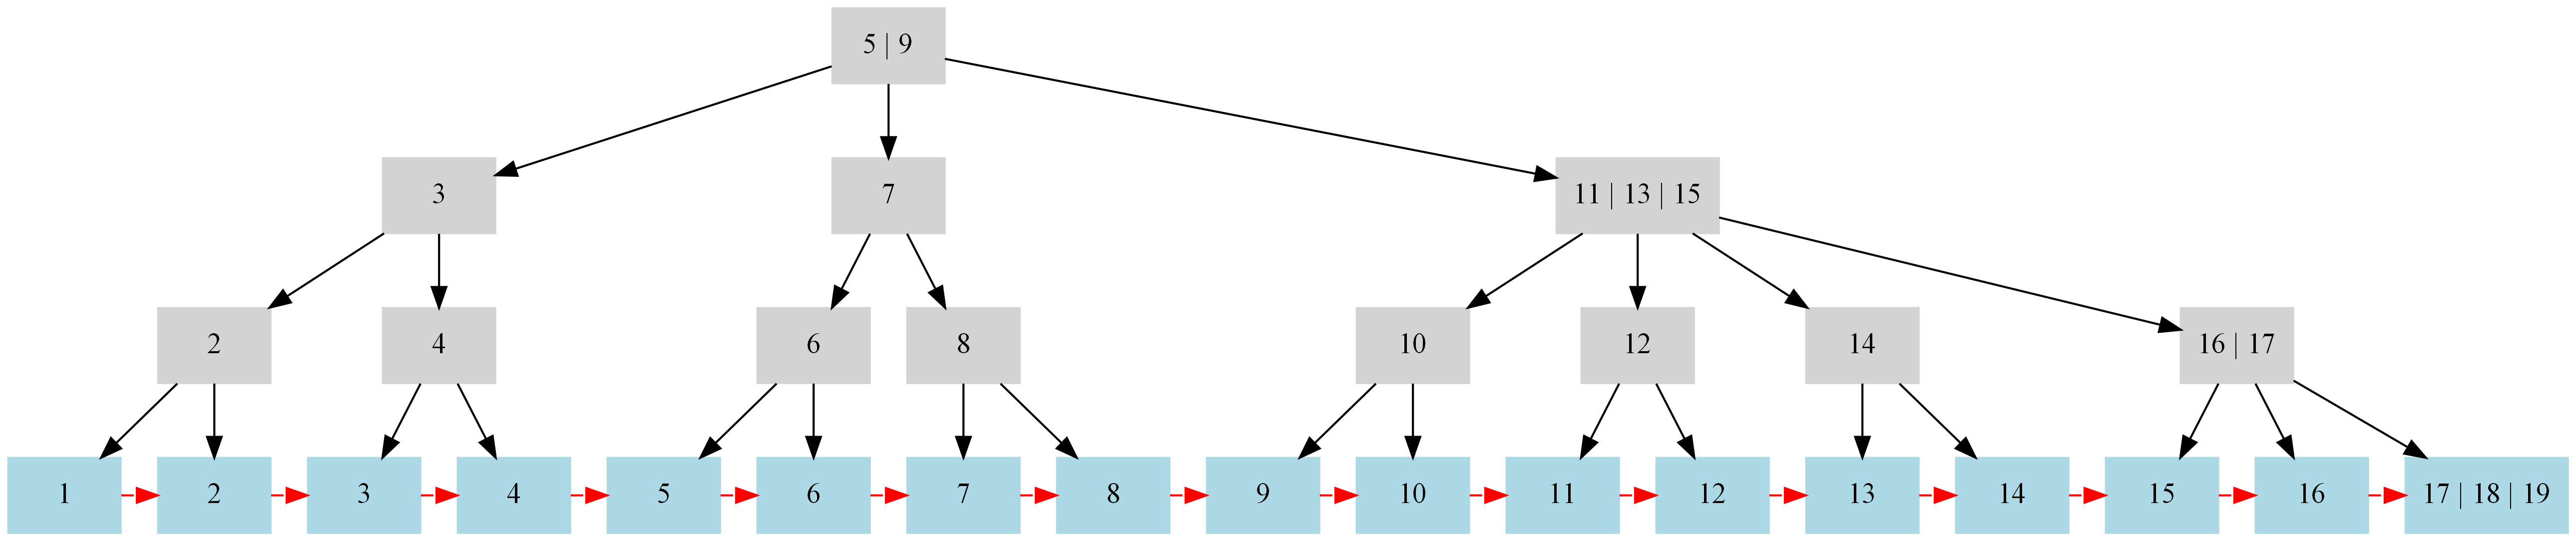

In [18]:
tree = bplustree(4)
for i in range(1, 20):
    tree.insert(i, str(i))

dot = tree.visualize_tree()
display(Image(dot.pipe(format='png')))

---
# Task 4 - Performance Benchmarking

### Data Generator

In [21]:
def generate_data(size):
    keys = random.sample(range(size * 10), size)
    search_keys = random.sample(keys, size // 2)
    delete_keys = random.sample(keys, size // 2)
    ranges = []
    for _ in range(size // 10):
        a, b = random.randint(0, size * 10), random.randint(0, size * 10)
        ranges.append((min(a, b), max(a, b)))
    return keys, search_keys, delete_keys, ranges

def run_benchmark(size):
    keys, search_keys, delete_keys, ranges = generate_data(size)
    operations = ["Insert", "Search", "Range", "Delete"]

    bpt = bplustree(4)
    an_bpt = PerformanceAnalyzer(bpt)
    time_bpt, mem_bpt = [], []
    for func, arg in [(an_bpt.insert_bulk, keys), (an_bpt.search_bulk, search_keys),
                      (an_bpt.range_bulk, ranges), (an_bpt.delete_bulk, delete_keys)]:
        t, m = an_bpt.measure_time_memory(func, arg)
        time_bpt.append(t); mem_bpt.append(m)

    bf = Bruteforceindex()
    an_bf = PerformanceAnalyzer(bf)
    time_bf, mem_bf = [], []
    for func, arg in [(an_bf.insert_bulk, keys), (an_bf.search_bulk, search_keys),
                      (an_bf.range_bulk, ranges), (an_bf.delete_bulk, delete_keys)]:
        t, m = an_bf.measure_time_memory(func, arg)
        time_bf.append(t); mem_bf.append(m)

    def plot_histogram(v1, v2, ylabel, title):
        x = np.arange(len(operations))
        width = 0.35
        plt.figure(figsize=(10, 6))
        bars1 = plt.bar(x - width/2, v1, width, label="B+ Tree")
        bars2 = plt.bar(x + width/2, v2, width, label="Brute Force")
        plt.ylabel(ylabel); plt.title(title)
        plt.xticks(x, operations); plt.legend()
        max_val = max(v1 + v2)
        plt.yticks(np.linspace(0, max_val, 6))
        for bar in bars1:
            h = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, h, f"{h:.4f}", ha='center', va='bottom')
        for bar in bars2:
            h = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, h, f"{h:.4f}", ha='center', va='bottom')
        plt.show()

    plot_histogram(time_bpt, time_bf, "Time (seconds)", f"Time Comparison (size={size})")
    plot_histogram(mem_bpt, mem_bf, "Memory (KB)", f"Memory Comparison (size={size})")

### Test at size = 100

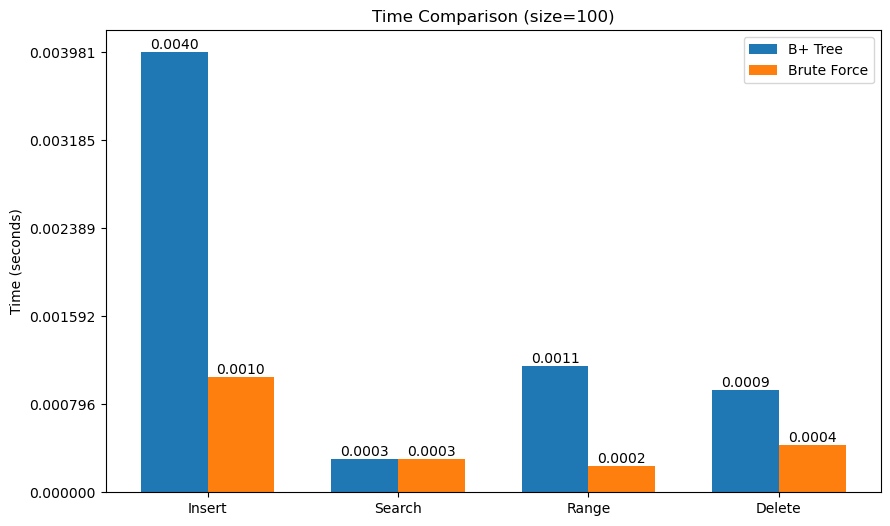

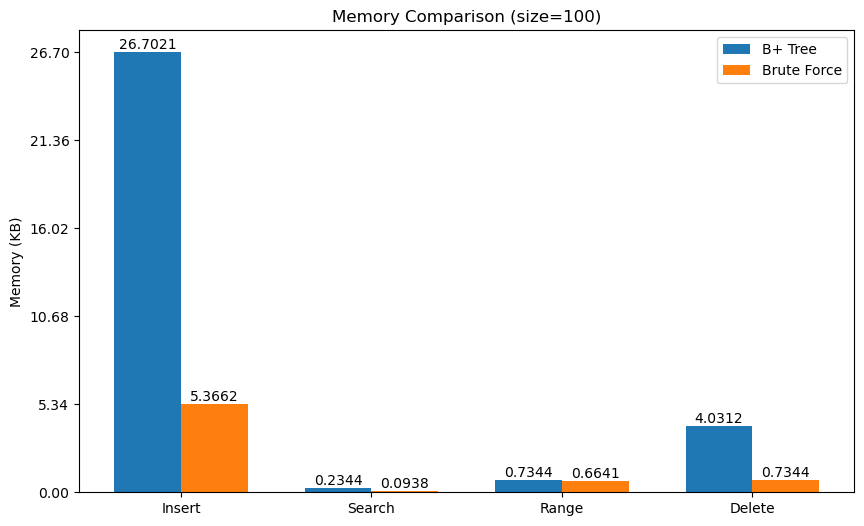

In [23]:
run_benchmark(100)

### Test at size = 1000

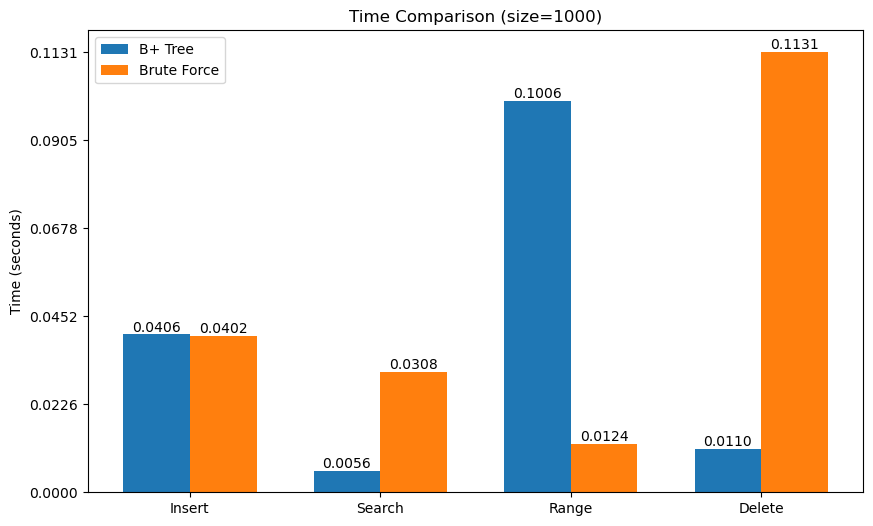

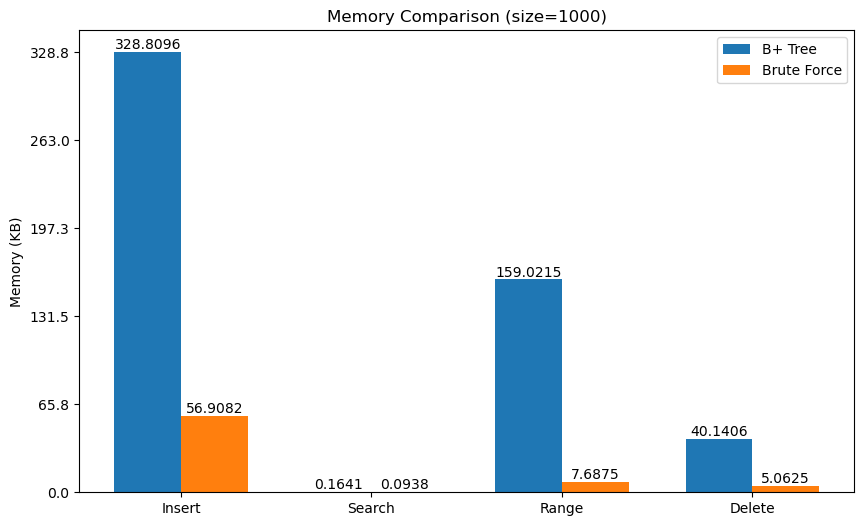

In [25]:
run_benchmark(1000)

### Test at size = 10000

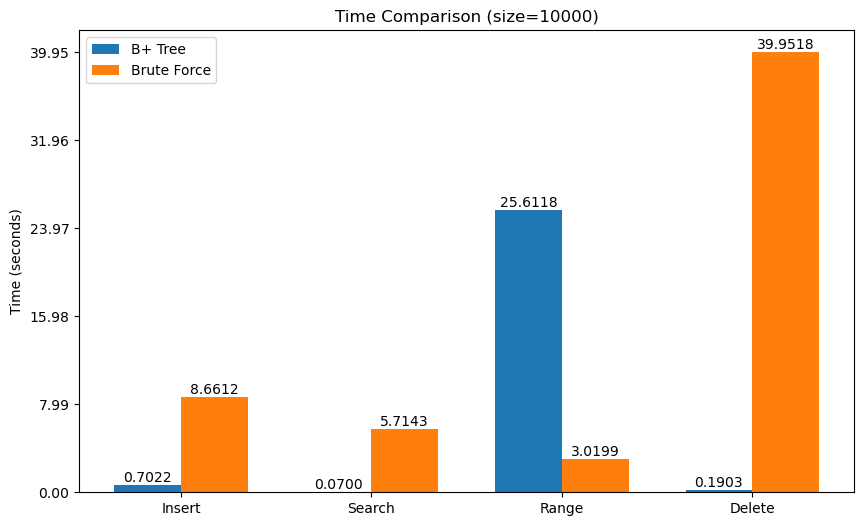

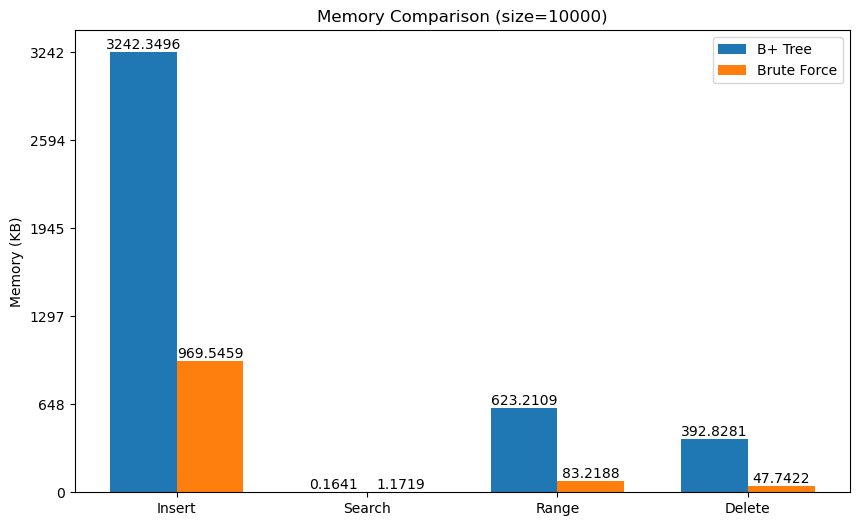

In [27]:
run_benchmark(10000)

### Scaling Comparison - B+ Tree vs BruteForce across sizes 1000 to 10000

Running size = 1000
Running size = 2000
Running size = 3000
Running size = 4000
Running size = 5000
Running size = 6000
Running size = 7000
Running size = 8000
Running size = 9000
Running size = 10000


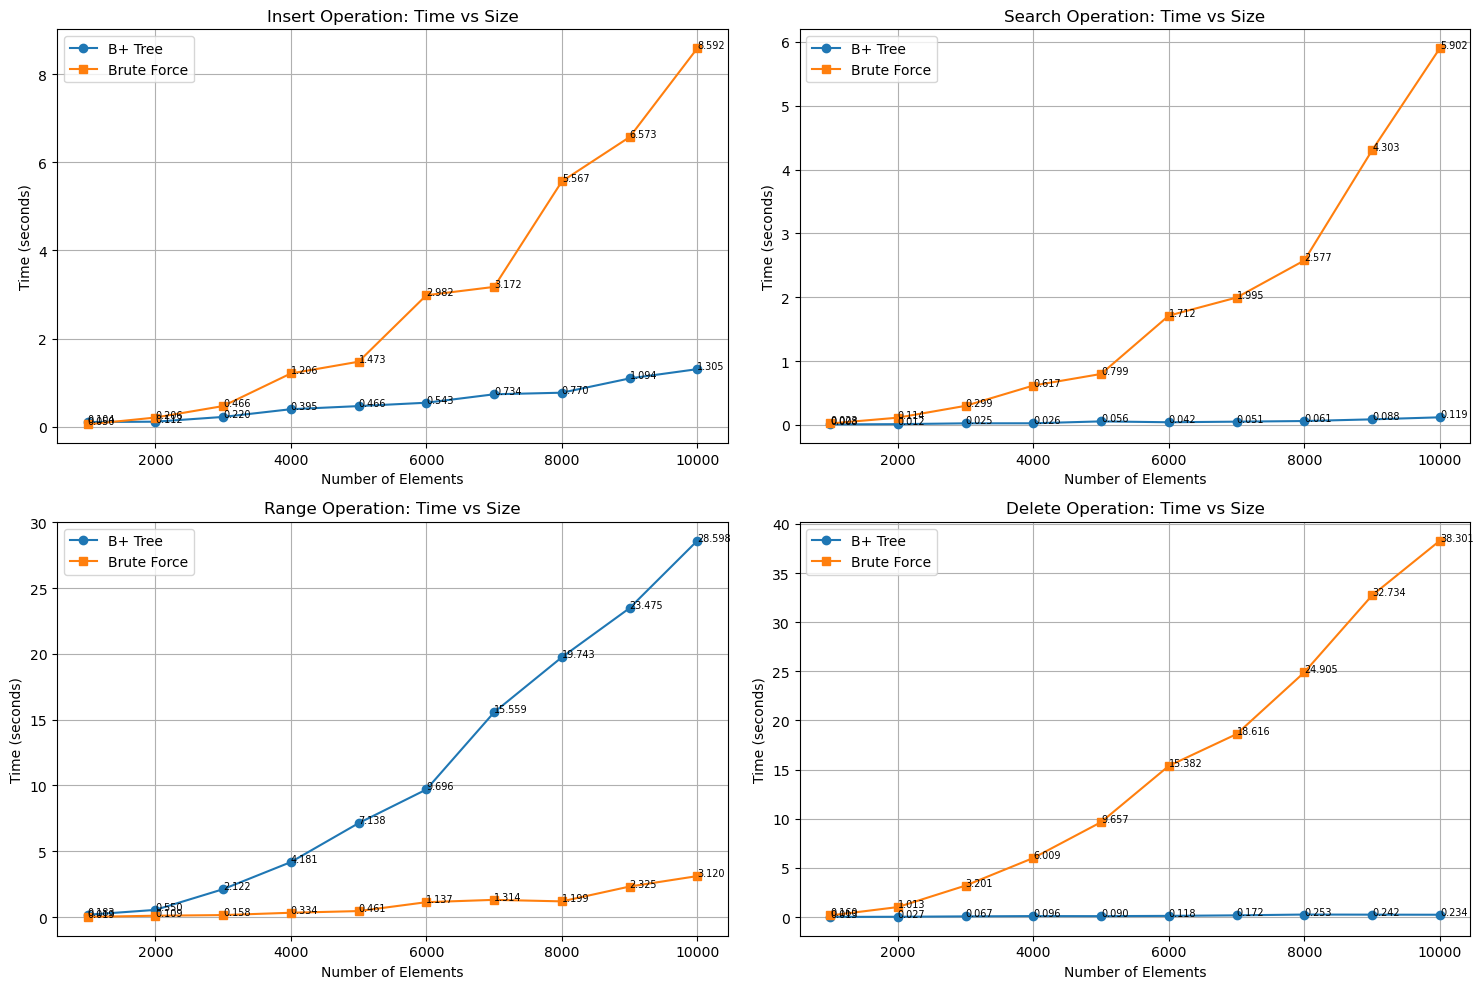

In [31]:
sizes = list(range(1000, 10001, 1000))
bpt_times = {"insert": [], "search": [], "range": [], "delete": []}
bf_times  = {"insert": [], "search": [], "range": [], "delete": []}

for size in sizes:
    print(f"Running size = {size}")
    keys, search_keys, delete_keys, ranges = generate_data(size)

    bpt = bplustree(4)
    an_bpt = PerformanceAnalyzer(bpt)
    bpt_times["insert"].append(an_bpt.measure_time_memory(an_bpt.insert_bulk, keys)[0])
    bpt_times["search"].append(an_bpt.measure_time_memory(an_bpt.search_bulk, search_keys)[0])
    bpt_times["range"].append(an_bpt.measure_time_memory(an_bpt.range_bulk, ranges)[0])
    bpt_times["delete"].append(an_bpt.measure_time_memory(an_bpt.delete_bulk, delete_keys)[0])

    bf = Bruteforceindex()
    an_bf = PerformanceAnalyzer(bf)
    bf_times["insert"].append(an_bf.measure_time_memory(an_bf.insert_bulk, keys)[0])
    bf_times["search"].append(an_bf.measure_time_memory(an_bf.search_bulk, search_keys)[0])
    bf_times["range"].append(an_bf.measure_time_memory(an_bf.range_bulk, ranges)[0])
    bf_times["delete"].append(an_bf.measure_time_memory(an_bf.delete_bulk, delete_keys)[0])

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
ops = ["insert", "search", "range", "delete"]

for i, op in enumerate(ops):
    ax = axes[i]
    ax.plot(sizes, bpt_times[op], marker='o', label="B+ Tree")
    ax.plot(sizes, bf_times[op],  marker='s', label="Brute Force")
    ax.set_xlabel("Number of Elements")
    ax.set_ylabel("Time (seconds)")
    ax.set_title(f"{op.capitalize()} Operation: Time vs Size")
    ax.legend(); ax.grid(True)
    for x, y in zip(sizes, bpt_times[op]):
        ax.text(x, y, f"{y:.3f}", fontsize=7)
    for x, y in zip(sizes, bf_times[op]):
        ax.text(x, y, f"{y:.3f}", fontsize=7)

plt.tight_layout()
plt.show()

### Summary Table - at size 10000

In [34]:
summary = {
    "Operation":      ["Insert", "Search", "Range Query", "Delete"],
    "B+ Tree (s)":    [bpt_times["insert"][-1], bpt_times["search"][-1],
                       bpt_times["range"][-1],  bpt_times["delete"][-1]],
    "BruteForce (s)": [bf_times["insert"][-1],  bf_times["search"][-1],
                       bf_times["range"][-1],   bf_times["delete"][-1]],
}
df = pd.DataFrame(summary).round(5)
df["Speedup (BF/BPT)"] = (df["BruteForce (s)"] / df["B+ Tree (s)"]).round(2)
display(df)

,Operation,B+ Tree (s),BruteForce (s),Speedup (BF/BPT)
0,Insert,1.30518,8.59214,6.58
1,Search,0.11947,5.90231,49.40
2,Range Query,28.59763,3.12002,0.11
3,Delete,0.23367,38.30106,163.91


**Speedup (BF/BPT)** is the ratio of BruteForce time to B+ Tree time:

$$\text{Speedup} = \frac{\text{BruteForce Time}}{\text{B+ Tree Time}}$$

- Speedup $> 1$ → B+ Tree is faster
- Speedup $< 1$ → BruteForce is faster

---
# Task 5 -- DatabaseManager and Table Demo

The `DatabaseManager` and `Table` classes are imported from the separate `.py` files in the same directory.

In [51]:
class Table:
    def __init__(self, name, schema, order=4, search_key=None):
        self.name = name
        self.schema = schema
        self.order = order
        self.data = bplustree(order)
        self.search_key = search_key

    def validate_record(self, record):
        
        for col in self.schema:
            if col not in record:
                print(f"Missing column '{col}' in record.")
                return False
        
        type_map = {"int": int, "str": str, "float": float, "bool": bool}
        for col, dtype in self.schema.items():
            expected_type = type_map.get(dtype)
            if expected_type and not isinstance(record[col], expected_type):
                print(f"Column '{col}' expects {dtype}, got {type(record[col]).__name__}.")
                return False
        return True

    def insert(self, record):
        if not self.validate_record(record):
            return
        key = record.get(self.search_key)
        if key is None:
            print(f"Search key '{self.search_key}' not found in record.")
            return
        self.data.insert(key, record)

    def get(self, record_id):
        found, value = self.data.search(record_id)
        if found:
            return value
        return None

    def get_all(self):
        return self.data.get_all()

    def update(self, record_id, new_record):
        if not self.validate_record(new_record):
            return False
        return self.data.update(record_id, new_record)

    def delete(self, record_id):
        return self.data.delete(record_id)

    def range_query(self, start_value, end_value):
        return self.data.range_query(start_value, end_value)

    def visualize(self):
        return self.data.visualize_tree(filename=self.name)

In [53]:
class DatabaseManager:
    def __init__(self):
        self.databases = {}

    def create_database(self, db_name):
        if db_name in self.databases:
            print(f"Database '{db_name}' already exists.")
            return
        self.databases[db_name] = {}
        print(f"Database '{db_name}' created.")

    def delete_database(self, db_name):
        if db_name not in self.databases:
            print(f"Database '{db_name}' not found.")
            return
        del self.databases[db_name]
        print(f"Database '{db_name}' deleted.")

    def list_databases(self):
        if not self.databases:
            print("No databases exist.")
            return []
        print("Databases:", list(self.databases.keys()))
        return list(self.databases.keys())

    def create_table(self, db_name, table_name, schema, order=4, search_key=None):
        if db_name not in self.databases:
            print(f"Database '{db_name}' not found.")
            return
        if table_name in self.databases[db_name]:
            print(f"Table '{table_name}' already exists in '{db_name}'.")
            return
        self.databases[db_name][table_name] = Table(table_name, schema, order, search_key)
        print(f"Table '{table_name}' created in database '{db_name}'.")

    def delete_table(self, db_name, table_name):
        if db_name not in self.databases:
            print(f"Database '{db_name}' not found.")
            return
        if table_name not in self.databases[db_name]:
            print(f"Table '{table_name}' not found in '{db_name}'.")
            return
        del self.databases[db_name][table_name]
        print(f"Table '{table_name}' deleted from database '{db_name}'.")

    def list_tables(self, db_name):
        if db_name not in self.databases:
            print(f"Database '{db_name}' not found.")
            return []
        tables = list(self.databases[db_name].keys())
        print(f"Tables in '{db_name}':", tables)
        return tables

    def get_table(self, db_name, table_name):
        if db_name not in self.databases:
            print(f"Database '{db_name}' not found.")
            return None
        if table_name not in self.databases[db_name]:
            print(f"Table '{table_name}' not found in '{db_name}'.")
            return None
        return self.databases[db_name][table_name]

Database 'university' created.
Databases: ['university']


['university']

Table 'students' created in database 'university'.
Tables in 'university': ['students']


['students']


--- Inserting records ---


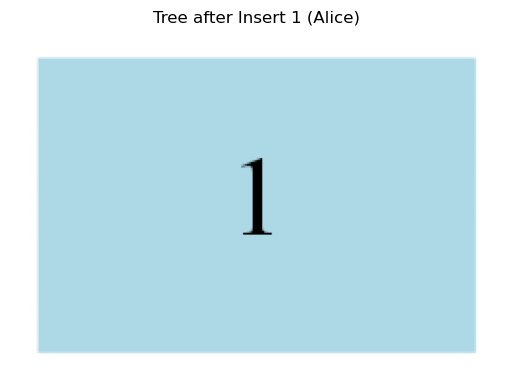

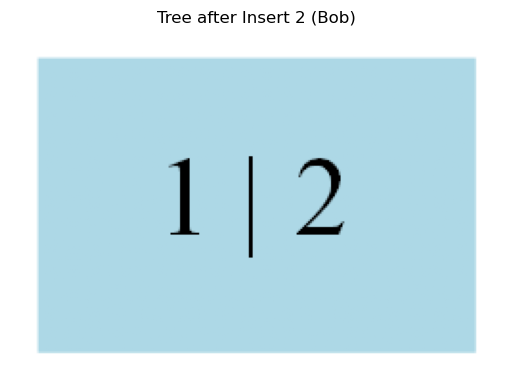

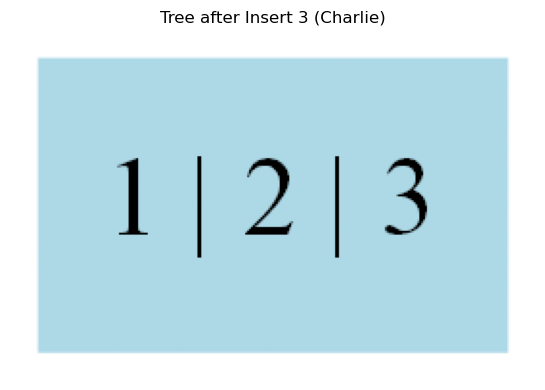

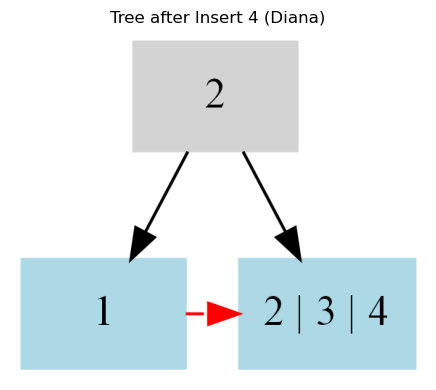

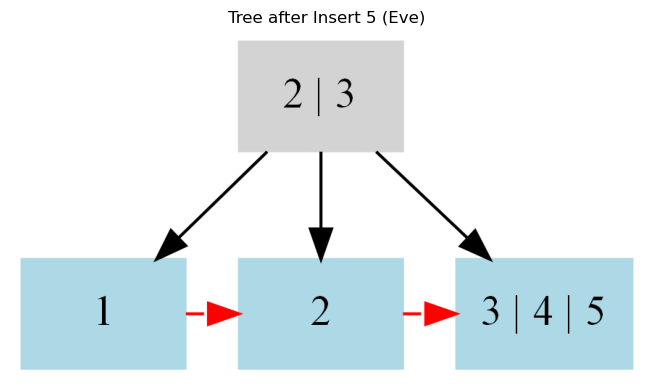

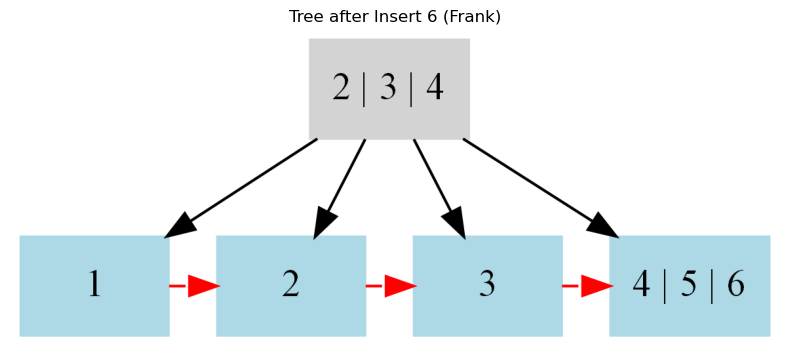

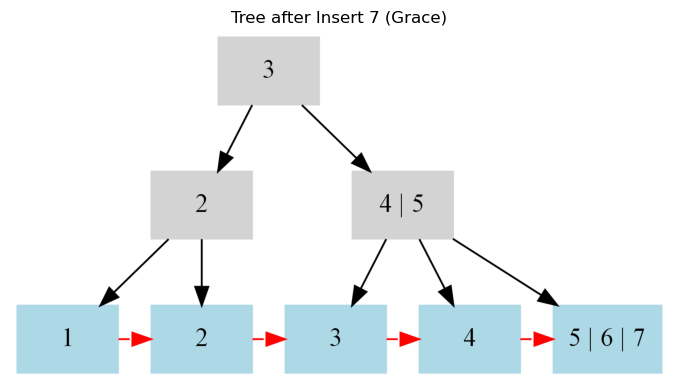

All records: [(1, {'student_id': 1, 'name': 'Alice', 'age': 20, 'branch': 'CS'}), (2, {'student_id': 2, 'name': 'Bob', 'age': 22, 'branch': 'EC'}), (3, {'student_id': 3, 'name': 'Charlie', 'age': 21, 'branch': 'ME'}), (4, {'student_id': 4, 'name': 'Diana', 'age': 23, 'branch': 'CS'}), (5, {'student_id': 5, 'name': 'Eve', 'age': 20, 'branch': 'CE'}), (6, {'student_id': 6, 'name': 'Frank', 'age': 24, 'branch': 'EC'}), (7, {'student_id': 7, 'name': 'Grace', 'age': 22, 'branch': 'CS'})]

--- Search student_id=3 ---
{'student_id': 3, 'name': 'Charlie', 'age': 21, 'branch': 'ME'}

--- Update student_id=3 ---


True

{'student_id': 3, 'name': 'Charlie Updated', 'age': 25, 'branch': 'ME'}

--- Range Query (2 to 5) ---
[(2, {'student_id': 2, 'name': 'Bob', 'age': 22, 'branch': 'EC'}), (3, {'student_id': 3, 'name': 'Charlie Updated', 'age': 25, 'branch': 'ME'}), (4, {'student_id': 4, 'name': 'Diana', 'age': 23, 'branch': 'CS'}), (5, {'student_id': 5, 'name': 'Eve', 'age': 20, 'branch': 'CE'})]

--- Delete student_id=4 ---


True

All records after delete: [(1, {'student_id': 1, 'name': 'Alice', 'age': 20, 'branch': 'CS'}), (2, {'student_id': 2, 'name': 'Bob', 'age': 22, 'branch': 'EC'}), (3, {'student_id': 3, 'name': 'Charlie Updated', 'age': 25, 'branch': 'ME'}), (5, {'student_id': 5, 'name': 'Eve', 'age': 20, 'branch': 'CE'}), (6, {'student_id': 6, 'name': 'Frank', 'age': 24, 'branch': 'EC'}), (7, {'student_id': 7, 'name': 'Grace', 'age': 22, 'branch': 'CS'})]


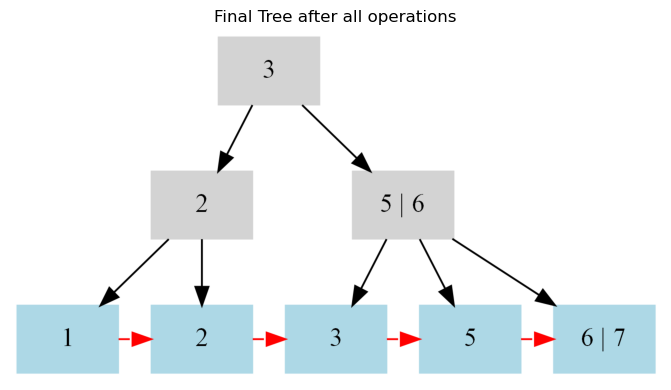

Table 'students' deleted from database 'university'.
Database 'university' deleted.


In [65]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io

def show_tree(tree, title=""):
    dot = tree.visualize_tree()
    png = dot.pipe(format='png')
    img = mpimg.imread(io.BytesIO(png))
    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(title)
    plt.tight_layout()
    plt.show()

db = DatabaseManager()
db.create_database("university")
db.list_databases()

student_schema = {
    "student_id": "int",
    "name": "str",
    "age": "int",
    "branch": "str"
}

db.create_table("university", "students",
                schema=student_schema, order=4, search_key="student_id")
db.list_tables("university")

t = db.get_table("university", "students")

# Insert records
print("\n--- Inserting records ---")
t.insert({"student_id": 1, "name": "Alice", "age": 20, "branch": "CS"})
show_tree(t.data, "Tree after Insert 1 (Alice)")

t.insert({"student_id": 2, "name": "Bob", "age": 22, "branch": "EC"})
show_tree(t.data, "Tree after Insert 2 (Bob)")

t.insert({"student_id": 3, "name": "Charlie", "age": 21, "branch": "ME"})
show_tree(t.data, "Tree after Insert 3 (Charlie)")

t.insert({"student_id": 4, "name": "Diana", "age": 23, "branch": "CS"})
show_tree(t.data, "Tree after Insert 4 (Diana)")

t.insert({"student_id": 5, "name": "Eve", "age": 20, "branch": "CE"})
show_tree(t.data, "Tree after Insert 5 (Eve)")

t.insert({"student_id": 6, "name": "Frank", "age": 24, "branch": "EC"})
show_tree(t.data, "Tree after Insert 6 (Frank)")

t.insert({"student_id": 7, "name": "Grace", "age": 22, "branch": "CS"})
show_tree(t.data, "Tree after Insert 7 (Grace)")

print("All records:", t.get_all())

# Search
print("\n--- Search student_id=3 ---")
print(t.get(3))

# Update
print("\n--- Update student_id=3 ---")
t.update(3, {"student_id": 3, "name": "Charlie Updated", "age": 25, "branch": "ME"})
print(t.get(3))

# Range Query
print("\n--- Range Query (2 to 5) ---")
print(t.range_query(2, 5))

# Delete
print("\n--- Delete student_id=4 ---")
t.delete(4)
print("All records after delete:", t.get_all())

# Final tree visualization
show_tree(t.data, "Final Tree after all operations")

# Cleanup
db.delete_table("university", "students")
db.delete_database("university")

---
## Conclusion

### Key Findings from Performance Analysis

- **Search:** B+ Tree significantly outperforms BruteForce at large sizes due to O(log n) traversal vs O(n) linear scan. The gap widens consistently as the dataset size grows.
- **Range Query:** The B+ Tree is slower than BruteForce for range queries because every step of the leaf traversal involves accessing Python object attributes (node.next, node.keys), which are expensive under the hood. BruteForce's list comprehension runs as a single optimised C-level loop, making it much faster in pure Python. Additionally, the B+ Tree must first traverse from the root to the starting leaf before scanning, adding extra overhead that BruteForce avoids entirely. This behaviour would reverse in a real disk-based database, where the B+ Tree's ability to minimise disk I/O makes it far superior.
- **Insert:** B+ Tree has slight overhead at small sizes due to splitting, but scales much better at large sizes with O(log n) complexity vs O(1) for BruteForce. BruteForce wins at very small sizes.
- **Delete:** Both are slower than search and insert. B+ Tree uses O(log² n) - it updates only the one affected separator key per level during recursion using `_leftmost_key`, which is a significant improvement over the naive O(n) full-tree refresh approach.
- **Memory:** B+ Tree uses more memory than BruteForce due to node pointers and tree structure overhead. This is a necessary tradeoff for the performance gains.
- Overall, the B+ tree performs far better than brute force, and it is a very robust and more efficient choice for scalability and practical deployment perspective
### Challenges Faced
- Correctly maintaining the `next` pointer chain during leaf splits and merges
- Ensuring internal separator keys stay accurate after deletions - solved by updating only the one affected separator per recursive level using `_leftmost_key` instead of a full tree refresh
- Handling edge cases where the root becomes empty after deletion
- Ensuring minimum key constraints are respected during deletion (borrow vs merge decision)

### Future Improvements
- Persist the tree to disk for permanent storage using serialization
- Support composite keys and multi-column indexing
- Implement concurrent access with locking mechanisms for multi-threaded environments

---
## Video Demonstration
[Google Drive / YouTube link ]